In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
t_zip = 0.079
t_container = 0.035

In [34]:
rs = np.linspace(0, 50_000_000, 100_000)


def c(rs: np.ndarray, t: float) -> np.ndarray:
    return rs * (0.2 / 1_000_000 + t * 0.5 * 0.0000166667)


fargate = np.full_like(rs, 17.76)
ec2 = np.full_like(rs, 14.96)

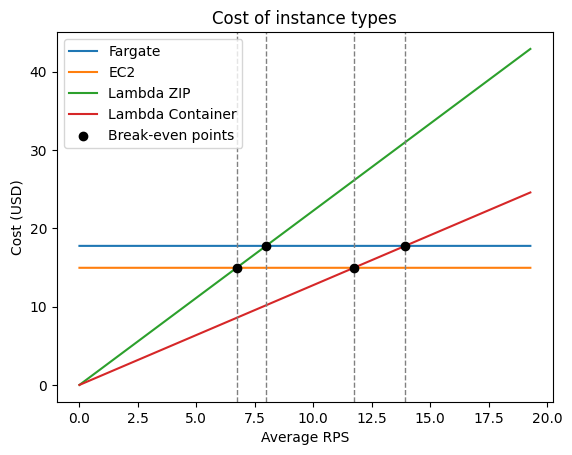

In [45]:
rps_factor = 30 * 24 * 60 * 60

plt.plot(rs / rps_factor, fargate, label="Fargate")
plt.plot(rs / rps_factor, ec2, label="EC2")
plt.plot(rs / rps_factor, c(rs, t_zip), label="Lambda ZIP")
plt.plot(rs / rps_factor, c(rs, t_container), label="Lambda Container")

break_even_xs = np.array([17429100, 30427082, 20691230, 36121991]) / rps_factor
break_even_ys = np.array([14.96, 14.96, 17.76, 17.76])

plt.scatter(
    break_even_xs,
    break_even_ys,
    label="Break-even points",
    color="black",
    zorder=5,
)

# Dashed lines to axes
for x in break_even_xs:
    plt.axvline(x, color="gray", linestyle="--", linewidth=1)

plt.title("Cost of instance types")
plt.xlabel("Average RPS")
plt.ylabel("Cost (USD)")
plt.legend()
plt.show()